# HTT Magspec analysis 

Magspec analysis originally written in Matlab by Kei Nakamura has been translated into python and integrated in this image analysis package. This example shows the basic usage and a benchmark against the original code

In [1]:
# define paths to find configs and set up logging
from geecs_data_utils.scan_data import ScanPaths
from geecs_data_utils.config_roots import image_analysis_config
from matplotlib import pyplot as plt
from pathlib import Path
import logging
import os
import numpy as np
import pandas as pd


logging.getLogger("image_analysis").setLevel(logging.WARNING)
logging.getLogger("geecs_data_utils").setLevel(logging.WARNING)


logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",
)


image_analysis_config.set_base_dir(ScanPaths.paths_config.image_analysis_configs_path)

img_analysis_dir = Path(os.getcwd()).parents[2] / "ImageAnalysis" / "image_analysis"
magspec_code_dir = img_analysis_dir / "magspec_code"
magspec_example_dir = magspec_code_dir / "example_data"
magspec_calibrations_dir = magspec_code_dir / "calibrations"

Here we simply verify the test images are imported correctly usign the basic beam analyzer

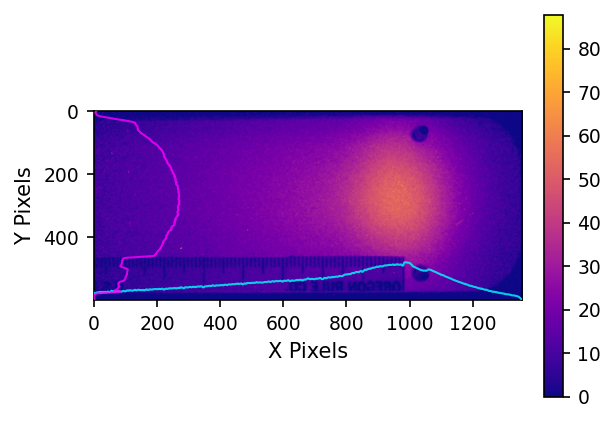

(599, 1357)

In [2]:
from image_analysis.offline_analyzers.magspec_manual_calib_analyzer import (
    MagSpecManualCalibAnalyzer,
)
from image_analysis.offline_analyzers.beam_analyzer import BeamAnalyzer

file_path_1 = (
    magspec_example_dir
    / "raw_data/HTT-C23_1_MagSpec1/Scan007_HTT-C23_1_MagSpec1_156.png"
)
file_path_2 = (
    magspec_example_dir
    / "raw_data/HTT-C23_2_MagSpec2/Scan007_HTT-C23_2_MagSpec2_156.png"
)

analyzer = BeamAnalyzer(camera_config_name="HTT-MagCam1")
res = analyzer.analyze_image_file(file_path_1)
analyzer.visualize(res)
res.processed_image.shape

Here we can directly inspect the calculation of the energy axis for a a given camera number and magnetic field. These values can be compared against existing saved data.

In [3]:
from image_analysis.offline_analyzers.magspec_manual_calib_analyzer import (
    DnnAxisCalibration,
)
from pathlib import Path

camera_calibration_file = magspec_calibrations_dir / "260224DnnVarianCam.txt"
trajectory_calibration_file = magspec_calibrations_dir / "170925DnnVarianTrj.txt"

# Build calibration object directly (Pydantic model — reads files on construction)
dnn_cal = DnnAxisCalibration(
    camera_calibration_file=str(camera_calibration_file),
    trajectory_calibration_file=str(trajectory_calibration_file),
    camera_number=2,
    magnetic_field_t=0.2003,
)

# Build pixel->energy axis
image_width = dnn_cal._x_end_px - dnn_cal._x_start_px + 1
energy_axis = dnn_cal.build_axis(image_width=image_width)

print(f"axis length: {len(energy_axis)}")
print(f"energy min/max: {energy_axis.min():.3f}, {energy_axis.max():.3f} MeV")
print(f"first/last: {energy_axis[0]:.3f}, {energy_axis[-1]:.3f} MeV")
energy_axis[:10]  # quick peek

axis length: 1001
energy min/max: 33.012, 74.956 MeV
first/last: 33.012, 74.956 MeV


array([33.01216596, 33.02808963, 33.04396888, 33.05979064, 33.0755553 ,
       33.09127229, 33.10695122, 33.12260171, 33.13823336, 33.15385578])

Run the full analysis pipeline for HTT-MagCam1 and 2

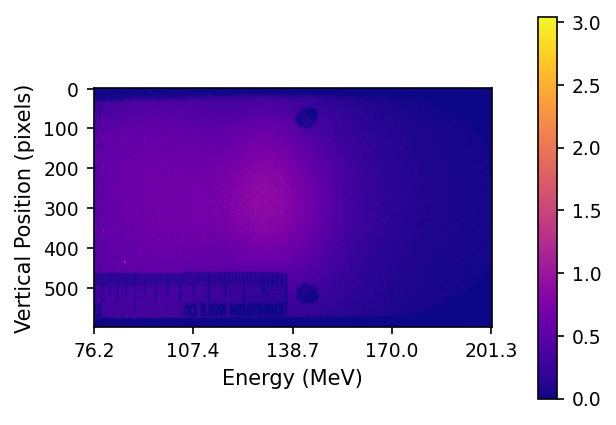

(<Figure size 600x600 with 2 Axes>,
 <Axes: xlabel='Energy (MeV)', ylabel='Vertical Position (pixels)'>)

In [6]:
analyzer_1 = MagSpecManualCalibAnalyzer(camera_config_name="HTT-MagCam1")
res_1 = analyzer_1.analyze_image_file(image_filepath=file_path_1)
analyzer_1.visualize(res_1)

2026-03-11 11:56:30,121 - image_analysis.algorithms.axis_interpolation - WARNING - Requested physical_min (10.200) below calibration range (33.045). Clipping to calibration minimum.
2026-03-11 11:56:30,121 - image_analysis.algorithms.axis_interpolation - WARNING - Requested physical_max (201.300) above calibration range (75.031). Clipping to calibration maximum.


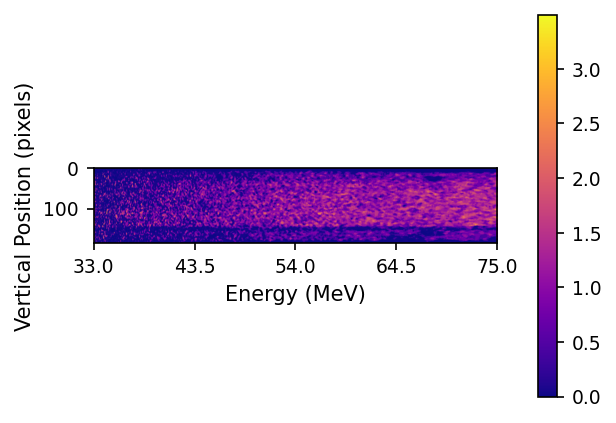

(<Figure size 600x600 with 2 Axes>,
 <Axes: xlabel='Energy (MeV)', ylabel='Vertical Position (pixels)'>)

In [7]:
analyzer_2 = MagSpecManualCalibAnalyzer(camera_config_name="HTT-MagCam2")
res_2 = analyzer_2.analyze_image_file(image_filepath=file_path_2)
analyzer_2.visualize(res_2)

Next, stitch the integrated results together the results from these two cameras and compare against the original result. Note, the background used for the python analysis was simply a single image from the background scan (not averaged) and there was no further 'lowpass' filtering on the python analyzed result. Overall, near perfect agreement.

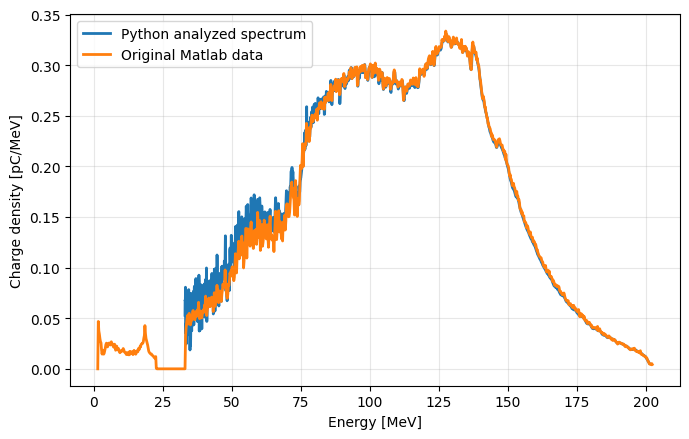

In [8]:
analyzed_data_path = (
    magspec_example_dir / "analyzed_data/MgspcHtt/Scan007_MgspcHttSpec_156.txt"
)
df = pd.read_csv(analyzed_data_path, sep="\t")

signal_calib_1 = np.sum(res_1.processed_image, axis=0) / 1000
energy_axis_1 = res_1.render_data["energy_axis"]
dE = np.diff(energy_axis_1)
E_center_1 = 0.5 * (energy_axis_1[:-1] + energy_axis_1[1:])

signal_calib_2 = np.sum(res_2.processed_image, axis=0) / 1000
energy_axis_2 = res_2.render_data["energy_axis"]
dE = np.diff(energy_axis_2)
E_center_2 = 0.5 * (energy_axis_2[:-1] + energy_axis_2[1:])

E_combined = np.concatenate([E_center_1, E_center_2])
signal_combined = np.concatenate([signal_calib_1[:-1], signal_calib_2[:-1]])

idx = np.argsort(E_combined)

plt.figure(figsize=(7, 4.5))

plt.plot(E_combined[idx], signal_combined[idx], lw=2, label="Python analyzed spectrum")
plt.plot(df.iloc[:, 0], df.iloc[:, 2], lw=2, label="Original Matlab data")

plt.xlabel("Energy [MeV]")
plt.ylabel("Charge density [pC/MeV]")

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()